In [5]:
# CLEAN + INSTALL EVERYTHING AT ONCE (CRITICAL)
!pip uninstall -y numpy opencv-python opencv-python-headless paddlepaddle paddleocr paddlex

!pip install -q \
numpy==1.26.4 \
opencv-python-headless==4.8.1.78 \
paddlepaddle==2.6.2 \
paddleocr==2.7.3 \
ultralytics supervision langchain langchain-text-splitters

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: opencv-python 4.13.0.92
Uninstalling opencv-python-4.13.0.92:
  Successfully uninstalled opencv-python-4.13.0.92
Found existing installation: opencv-python-headless 4.13.0.92
Uninstalling opencv-python-headless-4.13.0.92:
  Successfully uninstalled opencv-python-headless-4.13.0.92
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.9/125.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.0/780.0 kB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━

# Once restart session run the following code (NO more installs)

In [1]:
import os
os.environ["FLAGS_use_mkldnn"] = "False"

# Automatic License Plate Recognition (ALPR) pipeline

In [2]:
import kagglehub

path = kagglehub.dataset_download("andrewmvd/car-plate-detection")
print("Path to dataset:", path)

for file in os.listdir(path):
    print(file)

Using Colab cache for faster access to the 'car-plate-detection' dataset.
Path to dataset: /kaggle/input/car-plate-detection
annotations
images


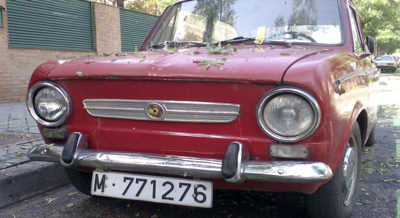

In [3]:
import cv2
from google.colab.patches import cv2_imshow

# Check image dataset
first_sample = os.listdir(f"{path}/images")[0]

sample_path = os.path.join(path, 'images', first_sample)
img = cv2.imread(sample_path)

cv2_imshow(img)

## Load YOLO model
- YOLO("yolov8n_lp.pt") → Weight file is specifically trained for plates, not cars, based on the YOLOv8 architecture. Loads YOLOv8 architecture.

Direct download:  
`!wget -O yolov8n_lp.pt "https://github.com/roboflow/notebooks/releases/download/v0.0.1/license_plate_detector.pt"`

- YOLO("yolov10n.pt") → Loads YOLOv10 architecture (NMS-free).

Direct download: `https://github.com/THU-MIG/yolov10/releases/download/v1.1/yolov10n.pt`

- YOLO("yolo26n.pt") → Loads the latest 2026 real-time architecture.

In [4]:
from ultralytics import YOLO
import supervision as sv
import matplotlib.pyplot as plt

# Load YOLO model
!wget -nc -O yolov10n.pt "https://github.com/THU-MIG/yolov10/releases/download/v1.1/yolov10n.pt"
model = YOLO('yolov10n.pt')


--2026-04-29 05:56:55--  https://github.com/THU-MIG/yolov10/releases/download/v1.1/yolov10n.pt
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/804788522/411e0d4f-1023-40ad-bfdd-c99f0dddb73b?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-04-29T06%3A33%3A20Z&rscd=attachment%3B+filename%3Dyolov10n.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-04-29T05%3A33%3A11Z&ske=2026-04-29T06%3A33%3A20Z&sks=b&skv=2018-11-09&sig=DdP75O7AFGo6sHx9las2pnt5kd1ixencCTggaiSw2kU%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3NzQ0NDAxNSwibmJmIjoxNzc3NDQyMjE1LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmNvcmUud2lu

In [5]:
from paddleocr import PaddleOCR

ocr = PaddleOCR(use_textline_orientation=True, lang='en')

download https://paddleocr.bj.bcebos.com/PP-OCRv3/english/en_PP-OCRv3_det_infer.tar to /root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer/en_PP-OCRv3_det_infer.tar


100%|██████████| 4.00M/4.00M [00:17<00:00, 232kiB/s] 


download https://paddleocr.bj.bcebos.com/PP-OCRv4/english/en_PP-OCRv4_rec_infer.tar to /root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer/en_PP-OCRv4_rec_infer.tar


100%|██████████| 10.2M/10.2M [00:21<00:00, 481kiB/s] 


download https://paddleocr.bj.bcebos.com/dygraph_v2.0/ch/ch_ppocr_mobile_v2.0_cls_infer.tar to /root/.paddleocr/whl/cls/ch_ppocr_mobile_v2.0_cls_infer/ch_ppocr_mobile_v2.0_cls_infer.tar


100%|██████████| 2.19M/2.19M [00:15<00:00, 139kiB/s]

[2026/04/29 05:58:00] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_length=25, rec_char_dict_path='

In [6]:
def run_alpr_2026(image_path):
    print(f"Processing media: {os.path.basename(image_path)}...")

    # Load original image (BGR) and convert for display (RGB)
    image_bgr = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    # STEP 1: Detect Plate Area with YOLO
    results = model(image_path)[0]

    # STEP 2: Filter and Map Detections
    detections = sv.Detections.from_ultralytics(results)
    detections = detections[detections.confidence > 0.55] # filter for only high-confidence objects (e.g., > 0.55).

    # STEP 3: OCR Recognition
    ocr_labels = []
    records = []
    print(f"Found {len(detections)} potential plates.")
    for bbox, conf in zip(detections.xyxy, detections.confidence):
    # for bbox in detections.xyxy:
        x1, y1, x2, y2 = map(int, bbox)

        # Crop the plate
        h, w = y2 - y1, x2 - x1
        pad = int(w * 0.05) # Add 5% padding
        plate_crop = image_bgr[max(0, y1-pad):y2+pad, max(0, x1-pad):x2+pad]

        # Pre-process for OCR (Grayscale)
        plate_gray = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2GRAY)
        # Convert grayscale to 3-channel for PaddleOCR (expects 3 channels)
        plate_rgb_for_ocr = cv2.cvtColor(plate_gray, cv2.COLOR_GRAY2BGR)

        # Recognize text
        ocr_res = ocr.ocr(plate_rgb_for_ocr)

        if ocr_res and ocr_res[0]: # Check if ocr_res is not empty and its first element (detections for the image) is not empty
            # Consolidate all text lines found (handles 2-line Thai plates).
            detected_string = " ".join([line[1][0] for line in ocr_res[0]]).upper()
        else:
            detected_string = "Unknown"

        print(f"\n Detected Plate: {detected_string} \n")
        ocr_labels.append(detected_string)

        records.append({
            "image": os.path.basename(image_path),
            "plate": detected_string,
            "confidence": float(conf),
            "bbox": [x1, y1, x2, y2]
        })

    plt.figure(figsize=(6, 4))
    plt.imshow(image_rgb)
    plt.title("Original Image", fontsize=15)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    return ocr_labels, records

Processing media: Cars393.png...

image 1/1 /kaggle/input/car-plate-detection/images/Cars393.png: 352x640 1 car, 1 truck, 308.2ms
Speed: 2.2ms preprocess, 308.2ms inference, 3.6ms postprocess per image at shape (1, 3, 352, 640)
Found 2 potential plates.
[2026/04/29 05:58:07] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/04/29 05:58:07] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.09204268455505371
[2026/04/29 05:58:07] ppocr DEBUG: rec_res num  : 1, elapsed : 0.10140490531921387

 Detected Plate: M771276 

[2026/04/29 05:58:07] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/04/29 05:58:07] ppocr DEBUG: dt_boxes num : 0, elapsed : 0.03056025505065918
[2026/04/29 05:58:07] ppocr DEBUG: rec_res num  : 0, elapsed : 1.9073486328125e-06

 Detected Plate: Unknown 



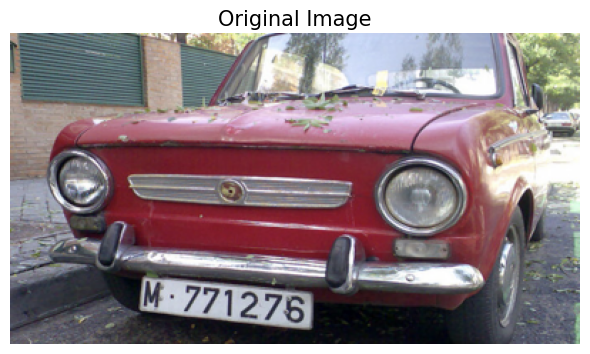

(['M771276', 'Unknown'],
 [{'image': 'Cars393.png',
   'plate': 'M771276',
   'confidence': 0.7676540017127991,
   'bbox': [17, 0, 381, 216]},
  {'image': 'Cars393.png',
   'plate': 'Unknown',
   'confidence': 0.567837119102478,
   'bbox': [371, 54, 398, 72]}])

In [7]:
run_alpr_2026(sample_path)

### Loop over multiple images


 ---------- image id 0 ---------- 

Processing media: Cars393.png...

image 1/1 /kaggle/input/car-plate-detection/images/Cars393.png: 352x640 1 car, 1 truck, 164.5ms
Speed: 4.4ms preprocess, 164.5ms inference, 0.4ms postprocess per image at shape (1, 3, 352, 640)
Found 2 potential plates.
[2026/04/29 05:58:14] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/04/29 05:58:14] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.05783891677856445
[2026/04/29 05:58:14] ppocr DEBUG: rec_res num  : 1, elapsed : 0.07788920402526855

 Detected Plate: M771276 

[2026/04/29 05:58:14] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/04/29 05:58:14] ppocr DEBUG: dt_boxes num : 0, elapsed : 0.012347221374511719
[2026/04/29 05:58:14] ppocr DEBUG: rec_res num  : 0, elapsed : 1.9073486328125e-06

 Detected Plate: Unknown 



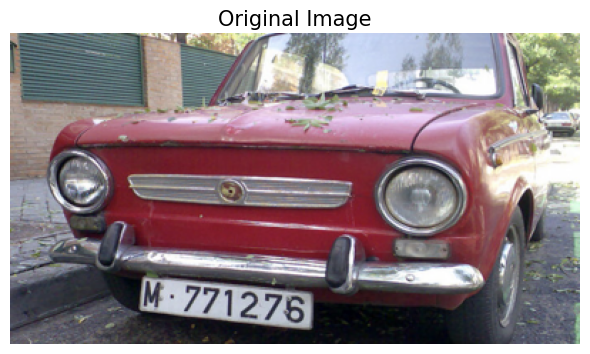


 ---------- image id 1 ---------- 

Processing media: Cars376.png...

image 1/1 /kaggle/input/car-plate-detection/images/Cars376.png: 448x640 1 car, 221.8ms
Speed: 5.2ms preprocess, 221.8ms inference, 0.3ms postprocess per image at shape (1, 3, 448, 640)
Found 1 potential plates.
[2026/04/29 05:58:15] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/04/29 05:58:15] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.12552666664123535
[2026/04/29 05:58:15] ppocr DEBUG: rec_res num  : 1, elapsed : 0.08066320419311523

 Detected Plate: B2228HM 



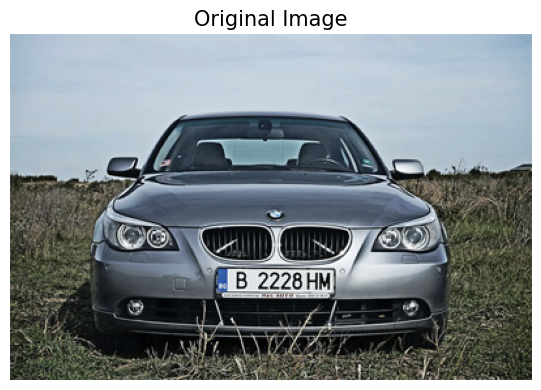


 ---------- image id 2 ---------- 

Processing media: Cars87.png...

image 1/1 /kaggle/input/car-plate-detection/images/Cars87.png: 480x640 5 cars, 273.6ms
Speed: 6.1ms preprocess, 273.6ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)
Found 3 potential plates.
[2026/04/29 05:58:16] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/04/29 05:58:16] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.1168680191040039
[2026/04/29 05:58:16] ppocr DEBUG: rec_res num  : 1, elapsed : 0.05816078186035156

 Detected Plate: GOP 

[2026/04/29 05:58:16] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/04/29 05:58:16] ppocr DEBUG: dt_boxes num : 0, elapsed : 0.054723501205444336
[2026/04/29 05:58:16] ppocr DEBUG: rec_res num  : 0, elapsed : 1.1920928955078125e-06

 Detected Plate: Unknown 

[2026/04/29 05:58:16] ppocr WARNING: Since the angle classifier is not

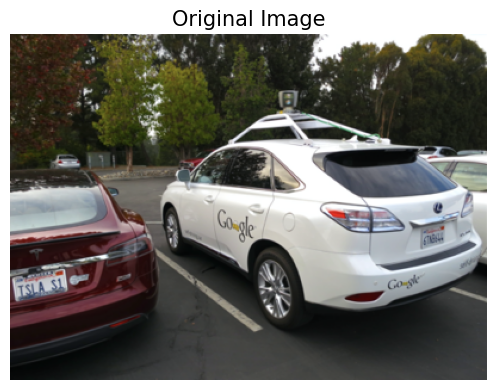


 ---------- image id 3 ---------- 

Processing media: Cars190.png...

image 1/1 /kaggle/input/car-plate-detection/images/Cars190.png: 480x640 1 car, 327.6ms
Speed: 4.9ms preprocess, 327.6ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)
Found 1 potential plates.
[2026/04/29 05:58:17] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/04/29 05:58:17] ppocr DEBUG: dt_boxes num : 3, elapsed : 0.11602330207824707
[2026/04/29 05:58:17] ppocr DEBUG: rec_res num  : 3, elapsed : 0.15759849548339844

 Detected Plate: TRUTHLIFEA JESUS. KL54-A-2670 



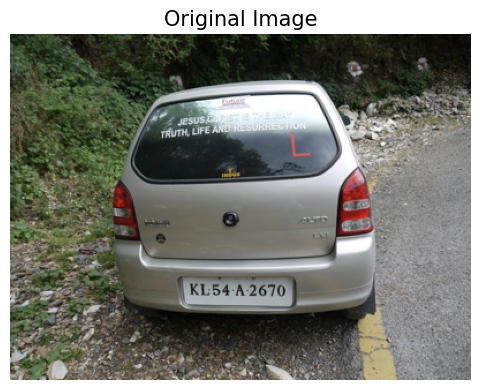


 ---------- image id 4 ---------- 

Processing media: Cars177.png...

image 1/1 /kaggle/input/car-plate-detection/images/Cars177.png: 384x640 3 cars, 343.6ms
Speed: 24.8ms preprocess, 343.6ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)
Found 3 potential plates.
[2026/04/29 05:58:18] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/04/29 05:58:18] ppocr DEBUG: dt_boxes num : 0, elapsed : 0.08685922622680664
[2026/04/29 05:58:18] ppocr DEBUG: rec_res num  : 0, elapsed : 1.6689300537109375e-06

 Detected Plate: Unknown 

[2026/04/29 05:58:18] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/04/29 05:58:18] ppocr DEBUG: dt_boxes num : 0, elapsed : 0.01862359046936035
[2026/04/29 05:58:18] ppocr DEBUG: rec_res num  : 0, elapsed : 1.1920928955078125e-06

 Detected Plate: Unknown 

[2026/04/29 05:58:18] ppocr WARNING: Since the angle classif

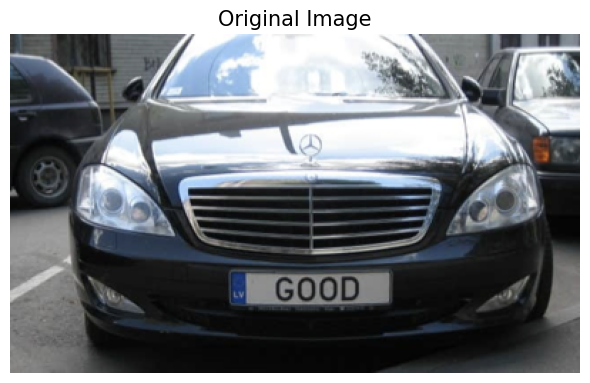

In [8]:
import glob
import pandas as pd
from pathlib import Path

image_paths = glob.glob(f"{path}/images/*.png")

plate_list, record_list, image_list = [],[],[]
for idx, im_path in enumerate(image_paths[:5]):
    print(f"\n ---------- image id {idx} ---------- \n")

    ocr_labels, records = run_alpr_2026(im_path)
    plate_list.append(ocr_labels)
    record_list.append(records)

    filename = Path(im_path).name
    image_list.append(filename)


In [9]:
df_plates = pd.DataFrame({
    'image_filename': image_list,
    'plate_number': plate_list
})
df_plates


,image_filename,plate_number
0,Cars393.png,"[M771276, Unknown]"
1,Cars376.png,[B2228HM]
2,Cars87.png,"[GOP, Unknown, Unknown]"
3,Cars190.png,[TRUTHLIFEA JESUS. KL54-A-2670]
4,Cars177.png,"[Unknown, Unknown, GOOD]"


In [10]:
flat_data = [item for sublist in record_list for item in sublist]

df_records = pd.DataFrame(flat_data)
df_records


,image,plate,confidence,bbox
0,Cars393.png,M771276,0.767654,"[17, 0, 381, 216]"
1,Cars393.png,Unknown,0.567837,"[371, 54, 398, 72]"
2,Cars376.png,B2228HM,0.902745,"[60, 57, 337, 247]"
3,Cars87.png,GOP,0.947114,"[125, 69, 396, 248]"
4,Cars87.png,Unknown,0.936182,"[0, 111, 126, 278]"
5,Cars87.png,Unknown,0.646675,"[348, 100, 399, 195]"
6,Cars190.png,TRUTHLIFEA JESUS. KL54-A-2670,0.886295,"[88, 40, 319, 246]"
7,Cars177.png,Unknown,0.864730,"[325, 8, 399, 136]"
8,Cars177.png,Unknown,0.840248,"[0, 14, 66, 122]"
9,Cars177.png,GOOD,0.705538,"[39, 0, 386, 227]"


In [17]:
# Check data getting only the highest-confidence detection per image
df_records_hconf = df_records.loc[df_records.groupby('image')['confidence'].idxmax()].reset_index(drop=True)
df_records_hconf


,image,plate,confidence,bbox
0,Cars177.png,Unknown,0.864730,"[325, 8, 399, 136]"
1,Cars190.png,TRUTHLIFEA JESUS. KL54-A-2670,0.886295,"[88, 40, 319, 246]"
2,Cars376.png,B2228HM,0.902745,"[60, 57, 337, 247]"
3,Cars393.png,M771276,0.767654,"[17, 0, 381, 216]"
4,Cars87.png,GOP,0.947114,"[125, 69, 396, 248]"


### Clean dataframe by getting only the known plates with highest-confidence detection per image

In [15]:
# Assign 0 to known plates and 1 to 'Unknown' so that known plates come first when sorting
new_df = df_records.copy()
new_df['is_unknown'] = (new_df['plate'].str.lower() == 'unknown').astype(int)

new_df_sorted = new_df.sort_values(
              by=['image', 'is_unknown', 'confidence'],
              ascending=[True, True, False]
)

# 3. Drop duplicates to keep only the first (best) row for each image
df_clean = new_df_sorted.drop_duplicates(subset='image').drop(columns=['is_unknown'])

print(df_clean)

         image                          plate  confidence                 bbox
9  Cars177.png                           GOOD    0.705538    [39, 0, 386, 227]
6  Cars190.png  TRUTHLIFEA JESUS. KL54-A-2670    0.886295   [88, 40, 319, 246]
2  Cars376.png                        B2228HM    0.902745   [60, 57, 337, 247]
0  Cars393.png                        M771276    0.767654    [17, 0, 381, 216]
3   Cars87.png                            GOP    0.947114  [125, 69, 396, 248]
